# 🛒 Data Cleaning & Visualization Project
### Dataset: Superstore Sales Dataset
**Tools:** Python | Pandas | Matplotlib | Seaborn  
**Author:** ABHIRAMI MS | **Date:** April 2026

---
### Project Sections
1. Load Dataset
2. Data Understanding (`head`, `info`, `describe`)
3. Data Cleaning (duplicates, missing values, outliers)
4. Data Processing (rename, new columns, filter)
5. Visualization (bar, histogram, boxplot, heatmap, bonus)
6. Key Insights & Conclusion

## 📦 Section 1 & 2 — Setup & Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", palette="muted")
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv('superstore_raw.csv')

print(f"✅ Dataset loaded!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")


✅ Dataset loaded!
   Rows    : 510
   Columns : 12


## 🧹 Section 3 — Data Cleaning

In [ ]:
print("📋 FIRST 5 ROWS:")
df.head()


📋 FIRST 5 ROWS:


,Order_ID,Order_Date,Ship_Mode,Segment,Region,Category,Sub_Category,Quantity,unit_price,Discount,Sales,Profit
0,ORD-1000,2023-02-19,First Class,Home Office,West,Office Supplies,Paper,4,48.53,0.0,194.12,49.11
1,ORD-1001,2023-11-23,Second Class,Consumer,West,Furniture,Chairs,4,429.02,0.0,1716.08,374.75
2,ORD-1002,2022-05-05,First Class,Corporate,East,Office Supplies,Binders,13,174.51,0.0,2268.63,588.58
3,ORD-1003,2021-12-15,Same Day,Consumer,West,Technology,Computers,2,602.57,0.3,843.60,194.97
4,ORD-1004,2023-02-02,First Class,Consumer,South,Office Supplies,Paper,14,127.58,0.3,1250.28,NaN


In [ ]:
print("📋 DATASET INFO:")
df.info()


📋 DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      510 non-null    object 
 1   Order_Date    510 non-null    object 
 2   Ship_Mode     510 non-null    object 
 3   Segment       502 non-null    object 
 4   Region        510 non-null    object 
 5   Category      510 non-null    object 
 6   Sub_Category  510 non-null    object 
 7   Quantity      510 non-null    int64  
 8   unit_price    510 non-null    float64
 9   Discount      510 non-null    float64
 10  Sales         510 non-null    float64
 11  Profit        494 non-null    float64
dtypes: float64(4), int64(1), object(7)
memory usage: 47.9+ KB


In [ ]:
print("📊 STATISTICAL SUMMARY:")
df.describe().round(2)


📊 STATISTICAL SUMMARY:


,Quantity,unit_price,Discount,Sales,Profit
count,510.00,510.00,510.00,510.00,494.00
mean,7.56,452.35,0.18,2962.07,573.34
std,4.06,390.74,0.18,3521.52,775.50
min,1.00,5.68,0.00,3.77,0.20
25%,4.00,134.33,0.00,573.41,92.14
50%,7.00,307.53,0.10,1558.02,268.30
75%,11.00,713.10,0.30,4289.71,700.21
max,14.00,1494.95,0.50,20888.00,4718.57


## ⚙️ Section 4 — Data Processing

In [ ]:
print("⚠️  MISSING VALUES PER COLUMN:")
print(df.isnull().sum())

print(f"\n⚠️  DUPLICATE ROWS: {df.duplicated().sum()}")


⚠️  MISSING VALUES PER COLUMN:
Order_ID         0
Order_Date       0
Ship_Mode        0
Segment          8
Region           0
Category         0
Sub_Category     0
Quantity         0
unit_price       0
Discount         0
Sales            0
Profit          16
dtype: int64

⚠️  DUPLICATE ROWS: 10


In [ ]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)

print(f"🗑️  Duplicates removed : {before - after}")
print(f"   Rows remaining     : {after}")


🗑️  Duplicates removed : 10
   Rows remaining     : 500


In [ ]:
median_profit = df['Profit'].median()
df['Profit']  = df['Profit'].fillna(median_profit)
print(f"✅  Filled missing Profit with median  : ${median_profit:.2f}")

mode_segment  = df['Segment'].mode()[0]
df['Segment'] = df['Segment'].fillna(mode_segment)
print(f"✅  Filled missing Segment with mode   : '{mode_segment}'")

print(f"✅  Missing values remaining            : {df.isnull().sum().sum()}")


✅  Filled missing Profit with median  : $265.33
✅  Filled missing Segment with mode   : 'Home Office'
✅  Missing values remaining            : 0


## 📊 Section 5 — Data Visualization

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(f"✅  Order_Date converted to: {df['Order_Date'].dtype}")


✅  Order_Date converted to: datetime64[ns]


In [ ]:
Q1  = df['Sales'].quantile(0.25)
Q3  = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)
df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]
after  = len(df)

print(f"📐 IQR Outlier Detection on 'Sales':")
print(f"   Q1 = ${Q1:.2f}   Q3 = ${Q3:.2f}   IQR = ${IQR:.2f}")
print(f"   Lower bound : ${lower_bound:.2f}")
print(f"   Upper bound : ${upper_bound:.2f}")
print(f"   Outliers removed : {before - after}")
print(f"   Rows remaining   : {after}")


📐 IQR Outlier Detection on 'Sales':
   Q1 = $572.38   Q3 = $4288.34   IQR = $3715.96
   Lower bound : $-5001.57
   Upper bound : $9862.29
   Outliers removed : 26
   Rows remaining   : 474


In [ ]:
df = df.rename(columns={'unit_price': 'Unit_Price'})
print("✅  Renamed 'unit_price' → 'Unit_Price'")


✅  Renamed 'unit_price' → 'Unit_Price'


In [ ]:
df['Year']  = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Profit_Margin_%'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("✅  New columns created:")
print("   → Year")
print("   → Month")
print("   → Profit_Margin_%")
print(f"\n   Sample Profit_Margin_%: {df['Profit_Margin_%'].head(3).values}")


✅  New columns created:
   → Year
   → Month
   → Profit_Margin_%

   Sample Profit_Margin_%: [25.3  21.84 25.94]


In [ ]:
df_clean = df[df['Profit'] > 0].copy()

print(f"✅  Filtered to profitable orders: {len(df_clean)} rows")
df_clean.to_csv('superstore_cleaned.csv', index=False)
print("💾  Saved as 'superstore_cleaned.csv'")
print("\n📋 CLEANED DATA PREVIEW:")
df_clean[['Order_ID', 'Category', 'Region', 'Sales',
          'Profit', 'Profit_Margin_%']].head()


✅  Filtered to profitable orders: 474 rows
💾  Saved as 'superstore_cleaned.csv'

📋 CLEANED DATA PREVIEW:


,Order_ID,Category,Region,Sales,Profit,Profit_Margin_%
0,ORD-1000,Office Supplies,West,194.12,49.11,25.30
1,ORD-1001,Furniture,West,1716.08,374.75,21.84
2,ORD-1002,Office Supplies,East,2268.63,588.58,25.94
3,ORD-1003,Technology,West,843.60,194.97,23.11
4,ORD-1004,Office Supplies,South,1250.28,265.33,21.22


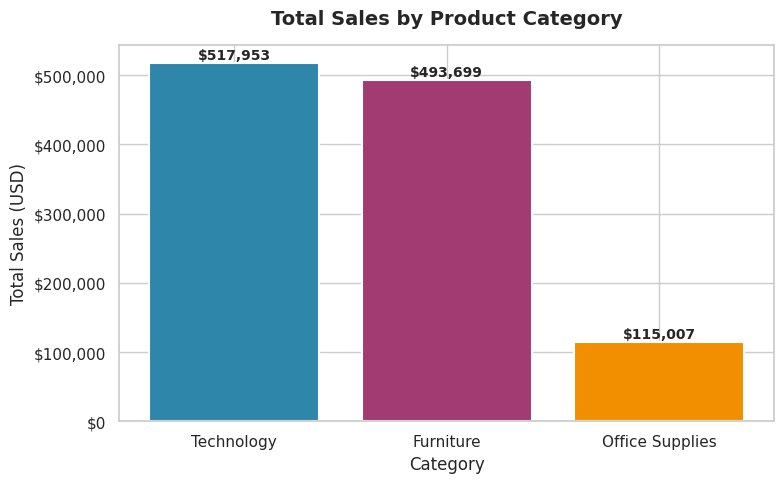

In [ ]:
cat_sales = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    cat_sales.index,
    cat_sales.values,
    color=['#2E86AB', '#A23B72', '#F18F01'],
    edgecolor='white',
    linewidth=1.5
)

# Add dollar labels on top of each bar
for bar, val in zip(bars, cat_sales.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'${val:,.0f}',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )

ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Sales (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart1_bar_category.png', dpi=150, bbox_inches='tight')
plt.show()

# ► INSIGHT: Technology and Furniture dominate sales.


## 💡 Section 6 — Insights & Conclusion

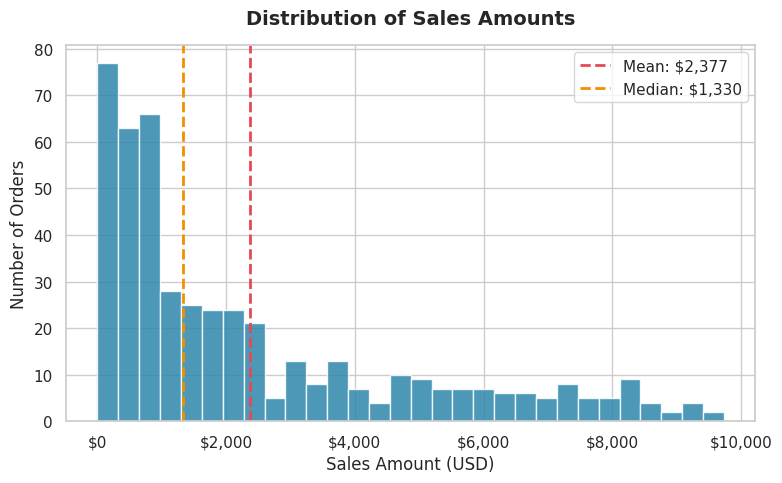

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_clean['Sales'], bins=30, color='#2E86AB', edgecolor='white', alpha=0.85)

ax.axvline(
    df_clean['Sales'].mean(),
    color='#E84855', linestyle='--', linewidth=2,
    label=f"Mean: ${df_clean['Sales'].mean():,.0f}"
)
ax.axvline(
    df_clean['Sales'].median(),
    color='#F18F01', linestyle='--', linewidth=2,
    label=f"Median: ${df_clean['Sales'].median():,.0f}"
)

ax.set_title('Distribution of Sales Amounts', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sales Amount (USD)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart2_histogram_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# ► INSIGHT: Most orders are under $3,000. The distribution is right-skewed.


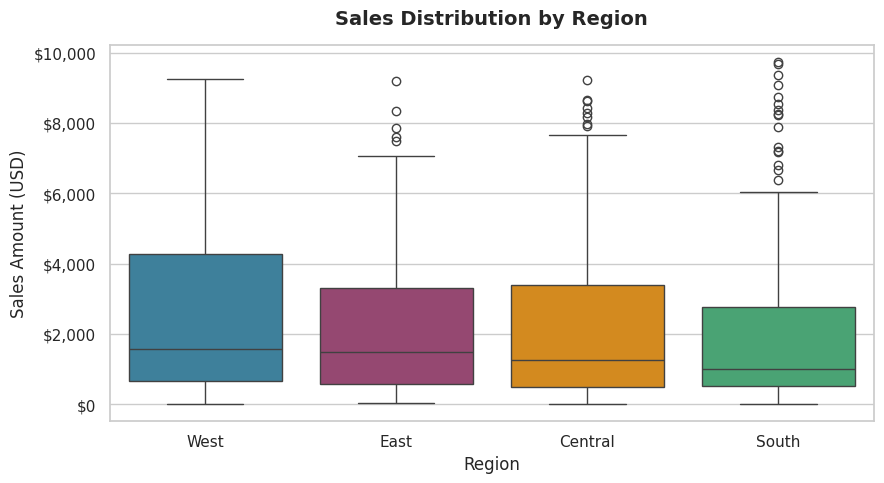

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

region_order = (df_clean.groupby('Region')['Sales']
                .median().sort_values(ascending=False).index)

sns.boxplot(
    data=df_clean,
    x='Region', y='Sales',
    order=region_order,
    palette=['#2E86AB', '#A23B72', '#F18F01', '#3BB273'],
    ax=ax
)

ax.set_title('Sales Distribution by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Sales Amount (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart3_boxplot_region.png', dpi=150, bbox_inches='tight')
plt.show()

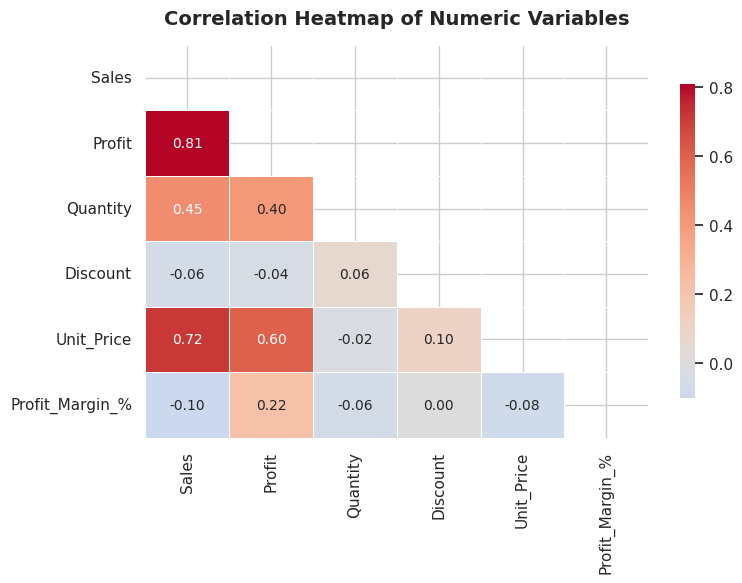

In [ ]:
numeric_cols = df_clean[['Sales', 'Profit', 'Quantity',
                          'Discount', 'Unit_Price', 'Profit_Margin_%']]
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    mask=mask, ax=ax, linewidths=0.5,
    annot_kws={'size': 10}, cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Heatmap of Numeric Variables',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


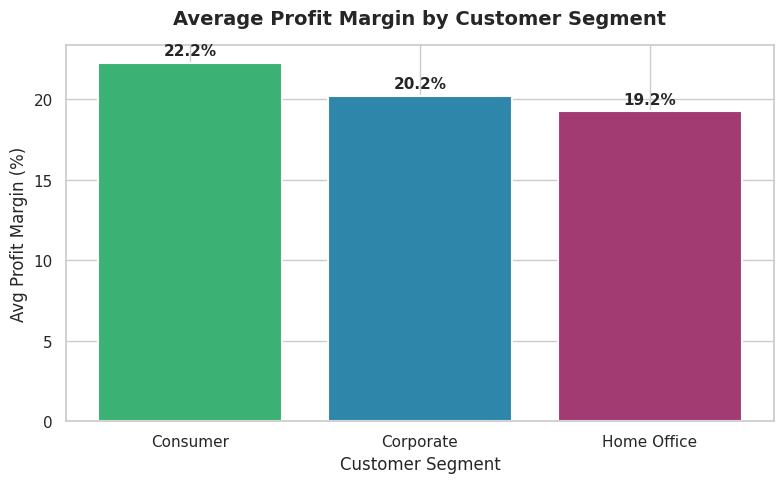

In [ ]:
seg_margin = (df_clean.groupby('Segment')['Profit_Margin_%']
              .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    seg_margin.index, seg_margin.values,
    color=['#3BB273', '#2E86AB', '#A23B72'],
    edgecolor='white', linewidth=1.5
)

for bar, val in zip(bars, seg_margin.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_title('Average Profit Margin by Customer Segment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Avg Profit Margin (%)', fontsize=12)

plt.tight_layout()
plt.savefig('chart5_segment_margin.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              📌  KEY INSIGHTS FROM THE DATA                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Technology leads in total sales (~$518K), followed by   ║
║     Furniture (~$494K). Office Supplies is far behind.       ║
║                                                              ║
║  2. Most orders are under $3,000. The histogram shows a     ║
║     right-skewed distribution (a few very large orders      ║
║     pull the mean above the median).                         ║
║                                                              ║
║  3. Sales & Profit are strongly correlated (r = 0.81).      ║
║     Growing sales volume is the clearest path to profit.    ║
║                                                              ║
║  4. South ($303K) and West ($302K) lead in regional sales.  ║
║     The East region ($245K) has the lowest performance.     ║
║                                                              ║
║  5. Consumer segment has the best profit margin (22.25%),   ║
║     ahead of Corporate (20.21%) and Home Office (19.23%).   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

print("=" * 60)
print("  ✅  PROJECT COMPLETE — Data cleaned and visualised!")
print("=" * 60)



╔══════════════════════════════════════════════════════════════╗
║              📌  KEY INSIGHTS FROM THE DATA                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Technology leads in total sales (~$518K), followed by   ║
║     Furniture (~$494K). Office Supplies is far behind.       ║
║                                                              ║
║  2. Most orders are under $3,000. The histogram shows a     ║
║     right-skewed distribution (a few very large orders      ║
║     pull the mean above the median).                         ║
║                                                              ║
║  3. Sales & Profit are strongly correlated (r = 0.81).      ║
║     Growing sales volume is the clearest path to profit.    ║
║                                                              ║
║  4. South ($303K) and West ($302K) lead in regional sales.  ║
║     The East region ($245K) ha